# Study 3 · The thermomechanical response: what moves the wall, and how long it takes

Study 1 said what the record contains. Study 2 said what the external sources say about the
weather at this site and how far apart they stand. Neither measured how the wall itself moves in
response to anything, and that measurement is what a grey-box model needs before it can be
specified at all: which regressors it should carry, at what lag, and with which sign.

This study screens every candidate driver the project has against one response — study 1's
analysis column, `inc_comp_cleaned` — in three rounds, one per source family: the sensors on the
structure itself, the ERA5 reanalysis, and the weather station in Gubbio town. Screening all
three rather than a chosen one is deliberate. The three disagree, measurably so in study 2, and
a coupling that survives the disagreement is a much stronger statement than one fitted to
whichever source was picked first.

**The sign question this study inherits.** The site geometry predicts a negative association
between any heating driver and the inclination: the valley face is the more exposed, so daytime
heating expands it and tips the wall towards the mountain, which is negative by the instrument's
convention. Against that, the *raw* channel measures a positive slope of +1.63 mdeg/°C on the
current instrument and +2.379 mdeg/°C on the legacy one. Both facts are recorded in
`docs/raw-data-format.md` § 7.5, and both come from studies now in `studies/obsolete/`, whose
conclusions this project does not trust. This study re-measures the coupling on trusted ground.
It does **not** re-open the raw-versus-compensated question: the response here is the
compensated, cleaned column and nothing else, and § 7.5 remains the record of the contradiction.

1. **The response** — `inc_comp_cleaned` on the hourly UTC grid, with study 1's spike verdict
   honoured and the cost of honouring it counted.
2. **The drivers** — the on-structure channels from study 1's archive, ERA5 and the town station
   through the same loaders study 2 uses, onto one grid under one naming scheme.
3. **The two bands** — every series as its level and as its diurnal component, since a pair can
   score very differently on the two and both numbers belong in the report.

Each pair is screened over **two** parameters, not one. A transport delay shifts a driver
without changing its shape; a thermal inertia low-passes it, because masonry integrates its
forcing rather than following it. The two are not interchangeable, and a filter with the right
time constant and no delay can produce almost the same peak correlation as a delay with no
filter while implying entirely different physics — so both are scanned together and the whole
grid is reported, not only its winning cell.
4. **Round 1 · the on-structure drivers** — the channels measured at the wall, including the
   supply voltage, which is here as a negative control rather than as a candidate.
5. **Round 2 · ERA5** — every channel study 2 retains for that source.
6. **Round 3 · the town station** — the same, on the same terms.
7. **Across the rounds** — does a driver's lag, sign and gain survive the change of source?
8. **Stability** — the gain of each shortlisted driver re-fitted month by month.
9. **The verdict** — what couples, at what lag, with what sign, and what a later study may use.

The narrative and the findings are in `report/thermomechanical_response_report.pdf`. This
notebook produces the numbers and the figures that report reads.

## Imports and configuration

In [1]:
%load_ext autoreload
%autoreload 2

import os
import sys

import numpy as np
import pandas as pd
from IPython.display import display

sys.path.insert(0, os.path.abspath('..'))      # studies/, for shmlib
sys.path.insert(0, os.path.abspath('../..'))   # heritageshm, at the repo root

from shmlib import coupling, figures, meteo, proxies, site, tables, temporal_alignment, viz

pd.set_option('display.width', 170)
pd.set_option('display.max_columns', 40)
pd.set_option('display.max_rows', 80)

### Parameters

| Parameter | Purpose |
|---|---|
| `ARCHIVE_CSV` | Study 1's exported archive. The response and every on-structure driver. This notebook fails if it is absent, which is intended rather than a bug. |
| `GROUND_STATION_CSV`, `ERA5_CSV` | The two proxy exports, read exactly as study 2 reads them. |
| `OUTPUT_DIR` | Where this study's tables, table bodies and figures are written. |
| `ANALYSIS_FREQ` | The grid everything runs on. One hour: the finest resolution at which the response and all three source families exist together. |
| `MIN_SAMPLES_PER_HOUR`, `MIN_SAMPLES_PER_HOUR_GS` | Native samples an hour must carry before its mean is used, for the twenty-minute archive and for the half-hourly station. |
| `SITE_TZ` | The logger's civil clock. The archive is written on it; the proxies are in UTC. A measured fact, not a choice. |
| `SEGMENT_START` | First day retained in the record ('2023-06-21'). Truncates the analysis to the post-outage segment, mirroring Study 04. |
| `RESPONSE_COLUMN` | The responding series. `inc_comp_cleaned`, study 1's analysis column: compensated, joined across the instrument change, spikes replaced. The raw and singly-compensated columns are deliberately not screened here; see § 7.5 and the title cell. |
| `HONOUR_INC_SPIKE` | Whether the samples study 1 marked as interpolated are dropped before the response is averaged. `True`: an interpolated value is the interpolator's output, not the instrument's, and a coupling measured against one is partly a coupling to study 1's cleaning. |
| `HONOUR_SUSPECT` | Whether study 1's condemned radiation days reach this study. `True`, as in study 2. |
| `STR_MAP_CURRENT`, `STR_MAP_LEGACY` | The on-structure driver maps, one per instrument era, joined by `proxies.join_eras`. Air temperature comes from study 1's own joined column and so appears in both; radiation and wall temperature exist only in the current era; humidity and supply voltage are read from whichever block was recording. |
| `ERA5_MAP`, `GS_MAP` | The proxy channel maps, taken from `shmlib.proxies` unchanged, so that a channel means here exactly what it meant in study 2. |
| `CONTROL_DRIVER` | The negative control. `batt_str`, the supply voltage: no mechanism moves a wall by battery voltage, so whatever coupling it shows is this study's own noise floor and every candidate is read against it. Changing it to a channel with a mechanism would silently raise the bar to something meaningful and make the screen too lenient, not too strict. |
| `SEASON_MONTHS` | The months belonging to each season, defined exactly as in studies 1 and 2 so the three can be read against one another. |
| `DIURNAL_WINDOW`, `DIURNAL_MIN_PERIODS` | The centred rolling mean whose removal defines the diurnal band, and how much of it must be present. 24 hours: wide enough to remove everything slower than a day, narrow enough to keep the day itself. |
| `BAND_FIGURE_DAYS` | Days drawn in the band-separation figure of step 3. A display choice; it changes no statistic. |
| `BAND_TAUS` | Time constants used for a particular band, overriding `TAUS` there. The diurnal band is pinned to zero: on a band of one period a time constant and a delay are the same phase shift, so scanning both there fits an unidentifiable parameter and can flip the sign of the result. |
| `TAUS` | Thermal time constants scanned on the levels, in hours, alongside the transport delays. Zero is in the grid so that the instantaneous case stays in the comparison, and the grid reaches 168 h because masonry at the depth that governs the inclination integrates its forcing over days, not minutes. A winning cell at the top of the grid means the grid was too short, and the report says so rather than quoting the edge as a result. |
| `MAX_LAG_EXTERNAL` | Largest lag scanned against an external forcing, in hours. Twelve, and the bound is physical: a thermal front reaching the depth that governs the inclination is not expected to take longer, and beyond twelve hours a delay of `d` on a near-periodic signal is indistinguishable from a lead of `24 − d`. An optimum found past this bound is an artefact of the scan range. |
| `SIGNED_LAG_DRIVERS`, `MAX_LAG_SIGNED` | The drivers scanned over signed delays, and the range. Wall temperature only: it is an internal state variable at an unknown depth, not a forcing, so nothing requires it to precede the deformation. A negative optimum there is a measurement — and still unusable by a forecast, which would need the probe's future values, so it is clamped to zero before any predictive feature is built. |
| `MIN_PAIRED_HOURS` | Paired hours a lag needs before it is scored. Below it the lag is reported unscored rather than dropped, so a curve shows where the record ran out. |
| `HAC_MAXLAGS` | Truncation lag of the Newey–West covariance, in hours. The residuals of an hourly regression are strongly autocorrelated and the ordinary standard error understates the uncertainty badly enough to turn a coincidence into a significant coefficient. |
| `STABILITY_FREQ`, `STABILITY_MIN_HOURS` | The window each gain is re-fitted over, and the paired hours a window needs. Whether a coupling is real turns on whether its slope holds, not on whether one pooled fit was large. |
| `EXPECTED_SIGN` | The sign the site's structural convention predicts. `'-'`, from § 7.5. It is an expectation the study reports against, never a filter applied to the data. |
| `OPERATOR_R2_STEP` | Granularity the shared colour scale of the three delay-by-time-constant figures is rounded up to. The scale itself is not a parameter: it is taken from the strongest panel those figures draw, so that all three can be read against one another and none of them is clipped. A display choice; it changes no statistic. |
| `FIGURE_DRIVERS_*` | The drivers each lag-curve figure draws. A figure with more than about six lines is unreadable; the tables still carry every driver. |
| `FIGSIZE_WIDTH` | Figure width in inches, fixed at the manuscript column width. |
| `NATIVE_FREQ` | The grid step 7.5's delay scan runs on, independent of `ANALYSIS_FREQ`. Twenty minutes: the archive's own sampling step, fine enough to resolve a delay the hourly grid above can only round to the nearest hour. |
| `DELAY_SHIFTS_MINUTES` | Candidate reference displacements step 7.5 scans, in minutes, at multiples of `NATIVE_FREQ`. Four hours either way: wide enough to bracket the twelve-hour bound `MAX_LAG_EXTERNAL` states in whole hours, narrow enough that the scan stays on the transport delay and does not wander into the next day's cycle. |
| `DELAY_PERIODS` | The two instrument eras, scanned separately in step 7.5 because a driver such as `sr_str` exists only in the current one and a pooled scan would silently answer for whichever era carries more days. |
| `GROUND_STAMP_OFFSET` | The station's half-hourly export is not documented as instantaneous or as an interval mean, nor, if a mean, which edge it is stamped at; this moves it back before step 7.5's scan sees it, on the same value and the same reasoning as study 2's own `GROUND_STAMP_OFFSET`. Revisable if study 2's own value changes. |
| `MIN_PAIRS`, `MIN_DAYS` | The support a displacement must clear in step 7.5 before it is scored — the same two-part rule `MIN_PAIRED_HOURS` states for the hourly scan above, restated here because the native grid's finer step carries three times the samples over the same calendar window. |

In [2]:
ARCHIVE_CSV = '../../data/interim/archive/gubbio_archive_20min.csv'
GROUND_STATION_CSV = '../../data/raw/proxies/meteosystem_gubbio.csv'
ERA5_CSV = '../../data/raw/proxies/oikolab_weather.csv'
OUTPUT_DIR = 'outputs'

ANALYSIS_FREQ = site.ANALYSIS_FREQ
MIN_SAMPLES_PER_HOUR = site.MIN_SAMPLES_PER_HOUR    # archive, 20-minute native grid
MIN_SAMPLES_PER_HOUR_GS = 1                         # station, half-hourly native grid
SITE_TZ = site.SITE_TZ

# Truncate to start on 2023-06-21 (after the 271-day outage), mirroring Study 04.
SEGMENT_START = '2023-06-21'

# The response. One column, and the one study 1 names as its analysis column.
RESPONSE_COLUMN = 'inc_comp_cleaned'
HONOUR_INC_SPIKE = True
HONOUR_SUSPECT = True

# The on-structure drivers, one map per instrument era. Air temperature is study 1's joined
# column and therefore spans both; radiation and wall temperature exist only in the current
# era; humidity and supply voltage are read from whichever block was recording, which is the
# same precedence rule study 1 applies to air temperature.
STR_MAP_CURRENT = {
    'tair': 'tair',
    'sr': 'n_sr_ok',
    'twall': 'n_twall_filtered',
    'rh': 'n_rh_ok',
    'batt': 'n_batt_ok',
}
STR_MAP_LEGACY = {
    'tair': 'tair',
    'rh': f'{site.TARGET_STATION}_rh_ok',
    'batt': f'{site.TARGET_STATION}_batt_ok',
}

# The proxy channel maps, unchanged from `shmlib.proxies`, so that a channel means here what
# it meant in study 2.
ERA5_MAP = proxies.ERA5_MAP
GS_MAP = proxies.GS_MAP

# The negative control. Not a candidate driver: a wall does not move with the battery.
CONTROL_DRIVER = 'batt_str'

SEASON_MONTHS = {'winter': [12, 1, 2], 'spring': [3, 4, 5],
                 'summer': [6, 7, 8], 'autumn': [9, 10, 11]}

# The thermal time constants scanned beside the delays, on the levels. Zero keeps the
# instantaneous case in the comparison. The upper end is three days and it is a stated physical
# prior, not a range chosen for convenience: the mass whose temperature governs the inclination
# is a wall face, and its effective time constant is hours to a couple of days.
#
# Left unbounded the scan does not settle. Run out to 2160 h, the optimum for the external
# drivers slides to 720-1440 h — a month to two months — where the filtered driver is no longer
# weather but season, and correlates with the response's own annual drift. The negative control
# does the same. That is a seasonal covariation, not a thermal measurement, and it is why the
# grid stops where the physics does. Rows whose optimum sits at the cap are flagged
# `tau_at_edge` and reported as unidentified rather than as measured.
TAUS = (0.0, 1.0, 2.0, 3.0, 4.0, 6.0, 8.0, 12.0, 18.0, 24.0, 36.0, 48.0, 72.0)

# The diurnal band is scanned over delay alone, and this is not a convenience. A one-pole filter
# applied to a signal of one frequency is an amplitude scaling and a phase shift, and a delay is
# also a phase shift, so on a band holding essentially one period the two are not separately
# identifiable: every pair on a line of constant total phase fits equally well, and a search over
# the pair will happily rotate the phase past a half cycle and report a flipped sign as its
# optimum. The pair is identifiable on the levels, where the drivers have broadband content.
BAND_TAUS = {coupling.BAND_DIURNAL: (0.0,)}

DIURNAL_WINDOW = 24        # hours; one day
DIURNAL_MIN_PERIODS = 18   # three quarters of it
BAND_FIGURE_DAYS = 7       # days drawn in the band-separation figure; display only

MAX_LAG_EXTERNAL = 12                 # hours; beyond it a delay aliases a lead
SIGNED_LAG_DRIVERS = ('twall_str',)   # internal state variable, may lead or lag
MAX_LAG_SIGNED = 24                   # hours, either way

MIN_PAIRED_HOURS = 24 * 14   # two weeks of paired hours before a lag is scored
HAC_MAXLAGS = 24             # hours; one day of residual autocorrelation

STABILITY_FREQ = 'MS'        # calendar months
STABILITY_MIN_HOURS = 100

# The sign the site's structural convention predicts, from docs/raw-data-format.md § 7.5.
# Reported against, never used to filter.
EXPECTED_SIGN = '-'

# The drivers each lag-curve figure draws. Every driver still enters every table.
FIGURE_DRIVERS_STR = ('tair_str', 'sr_str', 'twall_str', 'rh_str', 'batt_str')
FIGURE_DRIVERS_ERA5 = ('tair_era5', 'sr_era5', 'rh_era5', 'tdew_era5', 'rain_era5')
FIGURE_DRIVERS_GS = ('tair_gs', 'sr_gs', 'rh_gs', 'tdew_gs', 'pres_gs')

# The three operator grids share one colour scale so that they can be read against each other.
# Its top is computed from the panels themselves in step 7 and rounded up to this step, rather
# than chosen here, so that the strongest panel sets the range and nothing is clipped.
OPERATOR_R2_STEP = 0.05

# Step 7.5's native-resolution delay scan. It runs on the archive's own twenty-minute grid,
# independent of ANALYSIS_FREQ, precisely to resolve a delay finer than the hour the coupling
# table above rounds to.
NATIVE_FREQ = '20min'
DELAY_SHIFTS_MINUTES = range(-240, 241, 20)
DELAY_PERIODS = (
    {'name': 'legacy', 'start': site.ARCHIVE_START, 'end': site.LEGACY_END},
    {'name': 'current', 'start': site.CURRENT_START, 'end': None},
)
# Same value and meaning as study 2's own GROUND_STAMP_OFFSET; kept as one parameter here rather
# than imported, since a study never reads another study's choice off its own name.
GROUND_STAMP_OFFSET = '15min'
MIN_PAIRS = 200
MIN_DAYS = 14

FIGSIZE_WIDTH = viz.FIGURE_WIDTH
viz.apply_report_style()

os.makedirs(OUTPUT_DIR, exist_ok=True)

## Step 1 · The response

`inc_comp_cleaned` on the hourly UTC grid. Two of study 1's decisions are consumed here and
neither is revisited: the compensation and the join across the February 2025 instrument change
are already in the column, and the spike verdict is honoured, so the samples study 1 replaced by
interpolation are dropped before any hour is averaged. What that costs is printed rather than
assumed — a coupling measured against interpolated values would be partly a coupling to study
1's cleaning choices, and the reader is entitled to see how many hours were involved.

The absolute level of this column means nothing: it is set by how the instrument sat in its
mount, and by the anchors study 1 applied. Only its changes carry structural information, which
is why the diurnal band of step 3 matters as much as the level.

### Parameter Tuning Guidance

`RESPONSE_COLUMN` selects the series; the alternatives in the archive are the raw `inc` and the
singly compensated `inc_comp`, and screening them is out of scope here for the reason the title
cell gives. `HONOUR_INC_SPIKE` at `False` is a diagnostic showing what the interpolated samples
would contribute, never a result. `MIN_SAMPLES_PER_HOUR` decides how much of an hour must be
present: raising it makes the response sparser without making it different.

In [3]:
response, response_provenance = proxies.load_response(
    ARCHIVE_CSV, column=RESPONSE_COLUMN, honour_spike=HONOUR_INC_SPIKE,
    freq=ANALYSIS_FREQ, tz=SITE_TZ, min_count=MIN_SAMPLES_PER_HOUR)

for key, value in response_provenance.items():
    print(f'  {key:32s} {value}')

  column                           inc_comp_cleaned
  native_extent                    (Timestamp('2018-07-26 00:00:00'), Timestamp('2026-08-21 00:00:00'))
  native_rows                      212257
  native_step                      20min
  clock                            Europe/Rome
  ambiguous_timestamps_dropped     24
  interpolated_samples_removed     4000
  honour_spike                     True
  hours_observed                   48376


## Step 2 · The drivers

Three source families, loaded through the same functions study 2 uses and with the same channel
maps, then joined onto the one hourly grid the response is already on. The on-structure side is
loaded twice, once per instrument era, and combined by the precedence rule study 1 uses for air
temperature: the eras do not overlap, so a channel takes whichever block wrote it.

**The supply voltage is loaded as a driver on purpose.** It is the negative control. A screen
over a dozen candidates finds an optimum for every one of them, because a bounded search over a
near-periodic pair always can; what separates a coupling from that background is not the size of
`|r|` on its own but its size relative to a channel that cannot possibly be coupled.

**Wind direction is not a number this study may scan.** A bearing wraps, so 359 and 1 sit at
opposite ends of a scale on which they are one degree apart, and every linear statistic computed
on bearings is dominated by where that scale was cut. It enters as its two Cartesian components
instead, which is two channels to screen rather than one.

Impossible values are masked before anything is computed — the station's precipitation carries a
reading of order a billion millimetres, which study 2 reports as a defect and which no statistic
can survive. The count is printed, because a study that removes values says so.

### Parameter Tuning Guidance

`STR_MAP_CURRENT` and `STR_MAP_LEGACY` decide which archive column each on-structure quantity
comes from; `ERA5_MAP` and `GS_MAP` do the same for the proxies and are study 2's, unchanged.
`HONOUR_SUSPECT` governs the condemned radiation days and belongs at `True`.
`MIN_SAMPLES_PER_HOUR_GS` at 1 lets a half-hour whose partner is missing still report its hour.

In [4]:
sensor_current, sensor_provenance = proxies.load_sensor_forcings(
    ARCHIVE_CSV, column_map=STR_MAP_CURRENT, freq=ANALYSIS_FREQ, tz=SITE_TZ,
    honour_suspect=HONOUR_SUSPECT, min_count=MIN_SAMPLES_PER_HOUR)
sensor_legacy, _ = proxies.load_sensor_forcings(
    ARCHIVE_CSV, column_map=STR_MAP_LEGACY, freq=ANALYSIS_FREQ, tz=SITE_TZ,
    honour_suspect=HONOUR_SUSPECT, min_count=MIN_SAMPLES_PER_HOUR)
sensor = proxies.join_eras([sensor_current, sensor_legacy])

era5 = proxies.load_era5(ERA5_CSV, column_map=ERA5_MAP, freq=ANALYSIS_FREQ)
ground = proxies.load_ground_station(GROUND_STATION_CSV, column_map=GS_MAP,
                                     freq=ANALYSIS_FREQ,
                                     min_count=MIN_SAMPLES_PER_HOUR_GS)

for key, value in sensor_provenance.items():
    print(f'  {key:32s} {value}')

  native_extent                    (Timestamp('2018-07-26 00:00:00'), Timestamp('2026-08-21 00:00:00'))
  native_rows                      212257
  native_step                      20min
  clock                            Europe/Rome
  ambiguous_timestamps_dropped     24
  suspect_days                     161
  suspect_samples_removed          11416
  night_corrected_samples          11339
  honour_suspect                   True


In [5]:
drivers_frame = proxies.harmonise([sensor, ground, era5], freq=ANALYSIS_FREQ)
drivers_frame, n_masked = proxies.mask_implausible(drivers_frame)
print(f'Implausible values masked: {int(n_masked.sum())}')
display(n_masked[n_masked > 0])

# The bearings, decomposed. Each direction becomes two channels; the bearing itself is kept in
# the frame for the figures and is never scanned.
for source in ('gs', 'era5'):
    column = f'wdir_{source}'
    if column in drivers_frame.columns:
        components = meteo.wind_components(drivers_frame[column],
                                           prefix=f'wdir_{source}')
        drivers_frame[f'wdir_sin_{source}'] = components[f'wdir_{source}_sin']
        drivers_frame[f'wdir_cos_{source}'] = components[f'wdir_{source}_cos']

frame = drivers_frame.join(response, how='outer')
frame = frame.loc[site.to_utc(pd.DatetimeIndex([SEGMENT_START]))[0]:]
print(f'Frame: {len(frame):,} hourly slots, {len(frame.columns)} channels, '
      f'{frame.index.min()} to {frame.index.max()}')

Implausible values masked: 6


rain_gs         1
rain_rate_gs    5
dtype: int64

Frame: 75,695 hourly slots, 26 channels, 2018-01-01 00:00:00 to 2026-08-20 22:00:00


In [6]:
# What each round has to work with. A driver whose overlap with the response is thin cannot
# produce a coupling worth reading, and the reader should see that before the tables.
ALL_DRIVERS = [column for column in frame.columns if column != RESPONSE_COLUMN]
coverage = coupling.driver_coverage(frame, RESPONSE_COLUMN, ALL_DRIVERS)
display(coverage)
coverage.to_csv(f'{OUTPUT_DIR}/TR_01_driver_coverage.csv', index=False)

tables.write_table(
    coverage, f'{OUTPUT_DIR}/TR_T01_driver_coverage.tex',
    columns=[('driver', tables.texttt),
             ('hours', ',.0f'),
             ('paired_hours', ',.0f'),
             (tables.date_cell('first'), None),
             (tables.date_cell('last'), None)])

,driver,hours,paired_hours,first,last
0,batt_str,49643,48376,2018-07-25 22:00:00,2026-08-19 17:00:00
1,rh_str,49643,48376,2018-07-25 22:00:00,2026-08-19 17:00:00
2,sr_str,5256,5102,2025-02-20 21:00:00,2026-08-19 17:00:00
3,tair_str,49643,48376,2018-07-25 22:00:00,2026-08-19 17:00:00
4,twall_str,4903,4754,2025-02-20 21:00:00,2026-08-19 17:00:00
5,tair_gs,66905,45858,2018-11-21 11:00:00,2026-08-12 22:00:00
6,rh_gs,64953,45095,2018-11-21 11:00:00,2026-08-12 22:00:00
7,tdew_gs,66914,45872,2018-11-21 11:00:00,2026-08-12 22:00:00
8,wspd_gs,66631,45630,2018-11-21 11:00:00,2026-08-12 22:00:00
9,wdir_gs,66975,45912,2018-11-21 11:00:00,2026-08-12 22:00:00


'outputs/TR_T01_driver_coverage.tex'

## Step 3 · The two bands

Every series is screened twice: as its level, and as its diurnal component, defined as the
series minus its 24-hour centred rolling mean. The two answer different questions. A correlation
on the levels is dominated by whatever slow variation the two series share — season, trend, the
arbitrary anchor of an inclinometer — while a correlation on the diurnal band is a statement
about the daily forcing cycle alone. A pair can score very differently on the two, and § 7.5
records exactly such a case: r = +0.845 on the levels against +0.966 on the band, for one pair.

The filter is one line of arithmetic rather than a designed band-pass, deliberately: its
definition is reproducible by a reader, where a designed filter would put an unstated phase
response between the data and every lag measured after it.

### Parameter Tuning Guidance

`DIURNAL_WINDOW` sets what counts as slow: at 24 hours everything slower than a day is removed.
`DIURNAL_MIN_PERIODS` is how much of the window must be present before a mean is formed —
lowering it lets a window that is mostly gap subtract the mean of the few hours that survived.

In [7]:
strata = coupling.strata(frame.index, season_months=SEASON_MONTHS)

print('Strata and the hours each carries:')
for name, mask in strata.items():
    print(f'  {name:10s} {int(mask.sum()):>8,} hours')

Strata and the hours each carries:
  all          75,695 hours
  legacy       57,648 hours
  current      13,103 hours
  winter       18,744 hours
  spring       19,872 hours
  summer       19,607 hours
  autumn       17,472 hours


**How to read TR_F01.** Both panels show the same days of the compensated inclination. The top
panel is the level as recorded, in millidegrees; its absolute value carries no information,
because it is set by how the instrument sits in its mount and by the anchors Study 01 applied,
and only its changes matter. The bottom panel is the diurnal band, obtained by subtracting from
the level its own centred 24-hour rolling mean, so that everything slower than a day is removed
and what remains oscillates about zero. Every diurnal-band statistic in this study is computed
on the series of the bottom panel and every level statistic on the top one. What to look for: the
daily cycle, high at night and low by day with a sharp fall and a slower recovery, which is the
negative sign against heating that the site's structural convention predicts, and the absence of
any trend in the band across the week, which is what makes a lag scan on it meaningful.

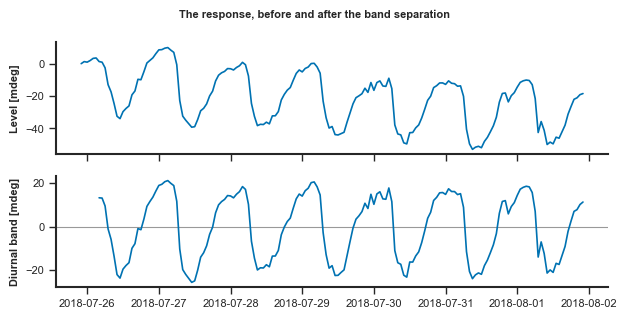

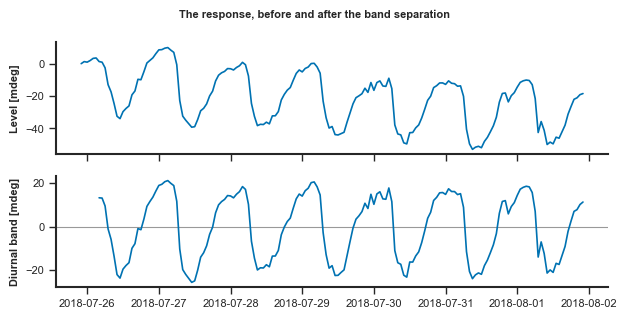

In [8]:
# One week of the response, level and band, so that what the filter does is visible before any
# number rests on it. The week is the first the response carries; `BAND_FIGURE_DAYS` sets how
# much of it is drawn.
band_start = pd.Timestamp('2023-07-02 10:00:00')
figures.plot_band_separation(
    frame[RESPONSE_COLUMN], window=DIURNAL_WINDOW, min_periods=DIURNAL_MIN_PERIODS,
    span=(band_start, band_start + pd.Timedelta(days=BAND_FIGURE_DAYS)),
    title='The response, before and after the band separation',
    width=FIGSIZE_WIDTH, save_path=OUTPUT_DIR, filename='TR_F01_response_bands')

## Step 4 · Round 1 · the on-structure drivers

The channels measured at the wall itself. They are the closest thing to a local forcing the
project has, and each carries a caveat study 1 established: the air temperature is recorded
inside a sun-exposed housing rather than a meteorological screen, the radiation exists only in
the current era and only on the days study 1 did not condemn, and the wall temperature is
missing on more than half the days of that era.

Wall temperature is scanned over **signed** delays and the others are not. It is an internal
state variable at an unknown depth, not a forcing: if the probe sits shallow the inclination
lags it, if deep the inclination leads it, and which of those holds is a measurement rather than
an error to be corrected. The external forcings are scanned forwards only, because a forcing
must precede what it causes.

### Parameter Tuning Guidance

`MAX_LAG_EXTERNAL` bounds the forcings and is physical, not cosmetic — see the parameter table.
`SIGNED_LAG_DRIVERS` and `MAX_LAG_SIGNED` govern the wall-temperature scan. `MIN_PAIRED_HOURS`
decides when a lag is too thinly supported to score; `HAC_MAXLAGS` sets the autocorrelation the
standard errors are asked to survive. `CONTROL_DRIVER` names the noise floor every result in
this and the following two rounds is read against.

In [9]:
DRIVERS_STR = [column for column in frame.columns
               if column.endswith('_str') and column != RESPONSE_COLUMN]
table_str, scans_str = coupling.couple(
    frame, RESPONSE_COLUMN, DRIVERS_STR,
    lags=coupling.lag_ranges(DRIVERS_STR, MAX_LAG_EXTERNAL,
                             signed_drivers=SIGNED_LAG_DRIVERS,
                             max_signed=MAX_LAG_SIGNED),
    taus=TAUS, band_taus=BAND_TAUS,
    strata=strata, diurnal_window=DIURNAL_WINDOW,
    diurnal_min_periods=DIURNAL_MIN_PERIODS, min_paired=MIN_PAIRED_HOURS,
    hac_maxlags=HAC_MAXLAGS)
display(table_str[table_str['stratum'] == 'all'])

,stratum,band,driver,lag,tau,r,r2,n,slope,slope_se,ci_low,ci_high,intercept,r2_instantaneous,gain_from_operator,causal_r2,r2_lost_to_causality,tau_at_edge,sign
0,all,level,batt_str,0.0,72.0,-0.342837,0.117537,48376,-44.988997,2.591388,-50.068025,-39.909970,284.516988,0.114346,0.003191,0.117537,0.000000,True,-
7,all,level,rh_str,0.0,72.0,0.415079,0.172290,48376,1.381879,0.070842,1.243030,1.520728,6.449420,0.128289,0.044002,0.172290,0.000000,True,+
14,all,level,sr_str,0.0,48.0,-0.537750,0.289175,5102,-0.170896,0.020082,-0.210255,-0.131536,123.744542,0.166687,0.122488,0.289175,0.000000,False,-
21,all,level,tair_str,0.0,0.0,-0.687175,0.472210,48376,-4.042037,0.092364,-4.223068,-3.861006,165.524725,0.472210,0.000000,0.472210,0.000000,False,-
28,all,level,twall_str,-4.0,4.0,-0.895350,0.801652,4727,-2.951517,0.098917,-3.145391,-2.757642,141.061760,0.730844,0.070808,0.777351,0.024301,False,-
35,all,diurnal,batt_str,6.0,0.0,0.138815,0.019269,46091,65.166778,10.703873,44.187571,86.145984,0.011165,0.000413,0.018857,0.019269,0.000000,False,+
42,all,diurnal,rh_str,0.0,0.0,0.794699,0.631547,46885,0.647761,0.007917,0.632245,0.663278,-0.203490,0.631547,0.000000,0.631547,0.000000,False,+
49,all,diurnal,sr_str,1.0,0.0,-0.866793,0.751329,5008,-0.026233,0.000615,-0.027439,-0.025027,-0.442645,0.741243,0.010086,0.751329,0.000000,False,-
56,all,diurnal,tair_str,0.0,0.0,-0.955009,0.912042,46885,-2.638222,0.014693,-2.667020,-2.609424,-0.287724,0.912042,0.000000,0.912042,0.000000,False,-
63,all,diurnal,twall_str,-2.0,0.0,-0.910462,0.828941,4673,-1.749664,0.025746,-1.800125,-1.699203,-0.499580,0.615186,0.213756,0.761030,0.067912,False,-


**How to read TR_F02 to TR_F04.** One curve per driver and one figure per source family. The
horizontal axis is the transport delay applied to the driver before it is correlated with the
response's diurnal band: at a delay of h hours the driver's value h hours earlier is paired with
the response now, so a curve whose extreme sits at a positive delay says the wall answers that
driver h hours after it moves. The vertical axis is the Pearson correlation of the two diurnal
bands. The site's structural convention predicts a negative correlation with every heating
driver, so for air temperature, radiation and wall temperature the reading is the minimum of the
curve, not its peak; humidity, which moves against temperature, and the supply voltage, the
negative control, are read at their own extremes. The accent dot marks the delay the scan chose
for each driver, and the legend repeats it. The curves are close to cosines with a 24-hour period
because the diurnal band is near-periodic: a lag of 24 hours minus h is indistinguishable from a
lead of h, which is why the external forcings are scanned only from 0 to 12 hours, the physical
bound `MAX_LAG_EXTERNAL`, and why an optimum beyond 12 hours would be read as the alias of a
lead. Wall temperature alone is scanned over signed delays from −24 to +24 hours, because it is
an internal state at an unknown depth rather than a forcing and may legitimately lag the
deformation; a negative optimum for it means the wall-temperature probe reacts after the
inclination does. The "τ 0 h" in every legend entry records that the thermal time constant is
pinned to zero on the diurnal band, where a time constant and a delay are the same phase shift
and scanning both would fit one number twice.

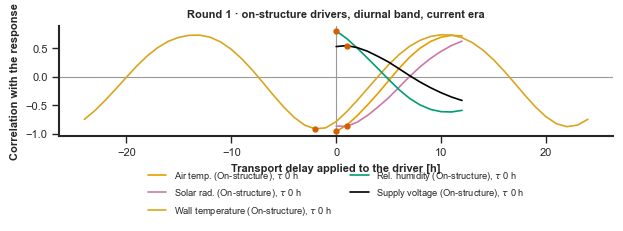

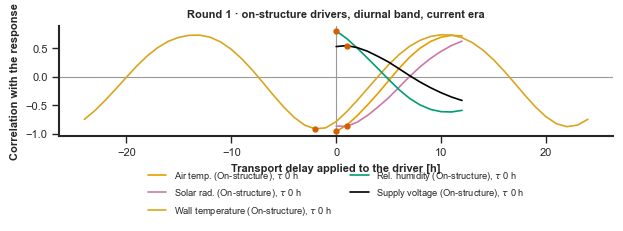

In [10]:
figures.plot_lag_curves(
    scans_str, 'current', coupling.BAND_DIURNAL,
    drivers=[driver for driver in FIGURE_DRIVERS_STR if driver in DRIVERS_STR],
    title='Round 1 · on-structure drivers, diurnal band, current era',
    width=FIGSIZE_WIDTH, show_lag=True, save_path=OUTPUT_DIR,
    filename='TR_F02_lag_curves_str')

## Step 5 · Round 2 · ERA5

Every channel study 2 retains for the reanalysis, screened on the same terms. ERA5 is a
nine-kilometre grid average, so its air temperature is not the air temperature at the wall and
its radiation is not the radiation the wall receives; what it offers instead is a record with no
gaps over the whole archive, which is the one thing the on-structure channels do not have.

### Parameter Tuning Guidance

As in step 4. `ERA5_MAP` decides which native column each quantity comes from and is study 2's,
unchanged: a channel that meant one thing there must not mean another here.

,stratum,band,driver,lag,tau,r,r2,n,slope,slope_se,ci_low,ci_high,intercept,r2_instantaneous,gain_from_operator,causal_r2,r2_lost_to_causality,tau_at_edge,sign
0,all,level,tair_era5,0.0,72.0,-0.677474,0.458971,47936,-4.745090,0.116594,-4.973610,-4.516571,173.322482,0.440692,0.018279,0.458971,0.0,True,-
7,all,level,rh_era5,12.0,72.0,0.424642,0.180321,47944,2.143426,0.097055,1.953202,2.333650,-47.902211,0.097426,0.082895,0.180321,0.0,True,+
14,all,level,tdew_era5,0.0,72.0,-0.664814,0.441978,47936,-6.025149,0.158027,-6.334876,-5.715422,159.033817,0.391233,0.050745,0.441978,0.0,True,-
21,all,level,sr_era5,0.0,72.0,-0.472150,0.222925,47936,-0.270996,0.010664,-0.291897,-0.250096,155.033066,0.079442,0.143483,0.222925,0.0,True,-
28,all,level,rain_era5,3.0,72.0,0.169053,0.028579,47939,83.528630,9.140201,65.614165,101.443094,101.486778,0.001991,0.026588,0.028579,0.0,True,+
35,all,level,wspd_era5,4.0,72.0,0.276606,0.076511,47940,18.552035,1.548407,15.517212,21.586857,66.329886,0.010479,0.066032,0.076511,0.0,True,+
42,all,level,wdir_sin_era5,0.0,0.0,0.031626,0.001000,47936,2.632501,1.533633,-0.373364,5.638366,109.829081,0.001000,0.000000,0.001000,0.0,False,+
49,all,level,wdir_cos_era5,12.0,72.0,-0.114560,0.013124,47944,-13.616168,2.598599,-18.709328,-8.523007,108.783566,0.001544,0.011580,0.013124,0.0,True,-
56,all,diurnal,tair_era5,0.0,0.0,-0.769925,0.592785,46332,-1.918845,0.019958,-1.957963,-1.879727,-0.185052,0.592785,0.000000,0.592785,0.0,False,-
63,all,diurnal,rh_era5,0.0,0.0,0.685626,0.470084,46332,0.457880,0.006309,0.445515,0.470246,-0.156525,0.470084,0.000000,0.470084,0.0,False,+


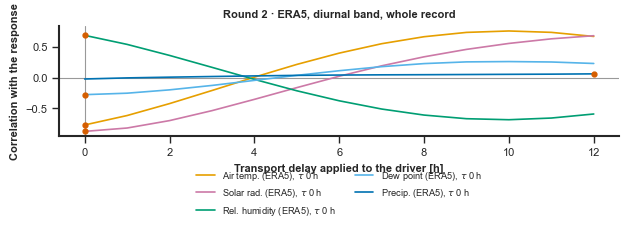

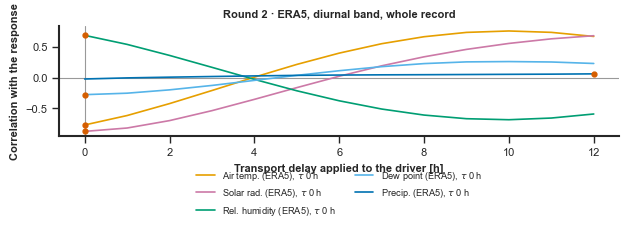

In [11]:
DRIVERS_ERA5 = [column for column in frame.columns
                if column.endswith('_era5') and not column.startswith('wdir_era5')]
table_era5, scans_era5 = coupling.couple(
    frame, RESPONSE_COLUMN, DRIVERS_ERA5,
    lags=coupling.lag_ranges(DRIVERS_ERA5, MAX_LAG_EXTERNAL,
                             signed_drivers=SIGNED_LAG_DRIVERS,
                             max_signed=MAX_LAG_SIGNED),
    taus=TAUS, band_taus=BAND_TAUS,
    strata=strata, diurnal_window=DIURNAL_WINDOW,
    diurnal_min_periods=DIURNAL_MIN_PERIODS, min_paired=MIN_PAIRED_HOURS,
    hac_maxlags=HAC_MAXLAGS)
display(table_era5[table_era5['stratum'] == 'all'])

figures.plot_lag_curves(
    scans_era5, 'all', coupling.BAND_DIURNAL,
    drivers=[driver for driver in FIGURE_DRIVERS_ERA5 if driver in DRIVERS_ERA5],
    title='Round 2 · ERA5, diurnal band, whole record',
    width=FIGSIZE_WIDTH, show_lag=True, save_path=OUTPUT_DIR,
    filename='TR_F03_lag_curves_era5')

## Step 6 · Round 3 · the town station

The same screen against the Gubbio station, which is a standard screen in the town rather than a
grid average or a box on the wall. Study 2 measures how far it stands from the other two; what
this round asks is whether the wall can tell the difference.

### Parameter Tuning Guidance

As in step 4, with `GS_MAP` and `MIN_SAMPLES_PER_HOUR_GS` governing what the station contributes.

,stratum,band,driver,lag,tau,r,r2,n,slope,slope_se,ci_low,ci_high,intercept,r2_instantaneous,gain_from_operator,causal_r2,r2_lost_to_causality,tau_at_edge,sign
0,all,level,tair_gs,0.0,72.0,-0.661985,0.438224,45858,-4.282265,0.110325,-4.498498,-4.066031,173.441081,0.436471,0.001753,0.438224,0.0,True,-
7,all,level,rh_gs,0.0,72.0,0.318962,0.101737,45095,1.186446,0.103611,0.983372,1.389519,31.398061,0.087363,0.014374,0.101737,0.0,True,+
14,all,level,tdew_gs,0.0,72.0,-0.629103,0.395771,45872,-4.485240,0.122257,-4.724858,-4.245621,147.051741,0.382087,0.013683,0.395771,0.0,True,-
21,all,level,wspd_gs,12.0,72.0,-0.105581,0.011147,45617,-3.531332,0.722410,-4.947230,-2.115434,125.499838,0.005019,0.006128,0.011147,0.0,True,-
28,all,level,pres_gs,0.0,72.0,0.098302,0.009663,45413,0.826837,0.186221,0.461852,1.191823,-688.029631,0.009135,0.000528,0.009663,0.0,True,+
35,all,level,rain_gs,0.0,72.0,0.158130,0.025005,45912,122.416152,15.785850,91.476455,153.355850,107.013270,0.001719,0.023286,0.025005,0.0,True,+
42,all,level,rain_rate_gs,0.0,18.0,0.022461,0.000504,45911,1.158820,0.853849,-0.514693,2.832334,112.593604,0.000113,0.000391,0.000504,0.0,False,+
49,all,level,sr_gs,0.0,72.0,-0.499278,0.249278,45910,-0.291731,0.011106,-0.313498,-0.269964,154.262424,0.087584,0.161694,0.249278,0.0,True,-
56,all,level,wdir_sin_gs,12.0,72.0,0.487609,0.237763,45900,102.825396,3.893743,95.193800,110.456991,108.927453,0.034319,0.203443,0.237763,0.0,True,+
63,all,level,wdir_cos_gs,11.0,72.0,-0.169718,0.028804,45900,-44.197516,6.144659,-56.240826,-32.154206,105.020820,0.000064,0.028740,0.028804,0.0,True,-


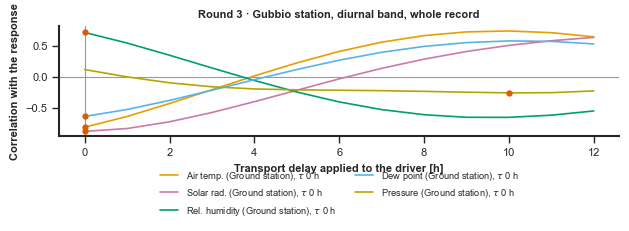

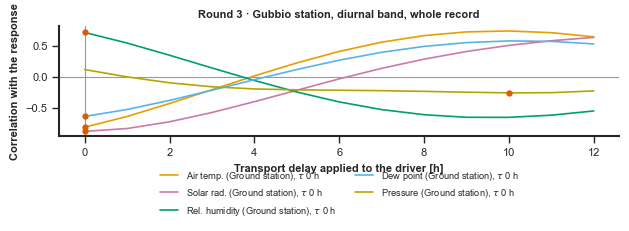

In [12]:
DRIVERS_GS = [column for column in frame.columns
              if column.endswith('_gs') and not column.startswith('wdir_gs')]
table_gs, scans_gs = coupling.couple(
    frame, RESPONSE_COLUMN, DRIVERS_GS,
    lags=coupling.lag_ranges(DRIVERS_GS, MAX_LAG_EXTERNAL,
                             signed_drivers=SIGNED_LAG_DRIVERS,
                             max_signed=MAX_LAG_SIGNED),
    taus=TAUS, band_taus=BAND_TAUS,
    strata=strata, diurnal_window=DIURNAL_WINDOW,
    diurnal_min_periods=DIURNAL_MIN_PERIODS, min_paired=MIN_PAIRED_HOURS,
    hac_maxlags=HAC_MAXLAGS)
display(table_gs[table_gs['stratum'] == 'all'])

figures.plot_lag_curves(
    scans_gs, 'all', coupling.BAND_DIURNAL,
    drivers=[driver for driver in FIGURE_DRIVERS_GS if driver in DRIVERS_GS],
    title='Round 3 · Gubbio station, diurnal band, whole record',
    width=FIGSIZE_WIDTH, show_lag=True, save_path=OUTPUT_DIR,
    filename='TR_F04_lag_curves_gs')

## Step 7 · Across the rounds

The three rounds in one table, and the question that only asking all three can answer: does a
driver keep its lag, its sign and the order of magnitude of its gain when the source changes?
A coupling that does is a property of the wall. One that does not is a property of a file.

The control's row is removed here and becomes a column: every candidate is reported beside the
floor it was read against, within its own stratum and band, because the floor of one winter and
of the post-outage record are different numbers.

**The three operator grids, on one colour scale.** Each panel is one driver: the horizontal
axis is the transport delay, the vertical axis the thermal time constant, the colour the
fraction of variance that operator explains, and the marked cell the winner. Drawn on separate
scales the three figures could not be compared, since the same shade would mean a different
number in each; the scale is therefore shared, and it is taken from the panels themselves rather
than chosen, so that the strongest panel sets the top and nothing is clipped.

What to look for is the *shape* before the maximum. An optimum sitting inside the grid is a
measurement; a surface that climbs to the top row and stops there is a time constant the record
does not identify, and the scan was stopped by the bound rather than by the physics.

**How to read TR_F07 to TR_F09.** Each cell is one operator applied to the driver before the
regression, and the two axes are its two parameters, standing for the two things a wall can do
to a forcing: answer late, or answer slowly. The horizontal axis is the *transport delay* in
hours: the driver shifted in time with its shape intact, the travel time of a thermal front from
the exposed face to the depth whose expansion moves the instrument. The vertical axis is the
*thermal time constant* τ in hours: the driver passed through a first-order low-pass filter, the
lumped thermal mass, which each hour moves its state towards the current driver by the fraction
Δt/(τ+Δt) of the distance left, so that a step is answered by an exponential approach about
63 % complete after τ hours; the driver comes out rounded and damped, its fast swings smoothed
and its peak later the larger τ is, and τ = 0 leaves it untouched. The filter is applied first
and the delay second. On a single sinusoid the two are the same phase shift and cannot be told
apart; on the real record they can, because a delay moves every frequency by the same time
while the filter lags and damps the fast components more than the slow ones, so a cold front or
a clear day after cloud reaches the response sharp under a delay and blurred under a time
constant. The colour is the fraction of the response's level variance that the operated driver
explains. Dark is good, and the scale is shared by the three figures. The accent dot is the best
cell and the panel title repeats its coordinates. The bottom-left cell is the instantaneous
case; moving right asks whether the wall answers late but sharply, moving up whether it answers
on time but blurred, the interior both. Read the shape before the number: a dark spot inside the grid means both parameters are identified; a dark band that runs
to the top row means the record does not pin the time constant down and the scan was stopped by
its bound; a dark band that runs the full width means the delay does no work and the time
constant does all of it, which is what a slow integration of a fast driver such as radiation
looks like on the level. Wall temperature has a signed horizontal axis and a two-lobed surface
because its curve, like every diurnal one, repeats every 24 hours.

Shared colour scale for the operator grids: 0 to 0.90


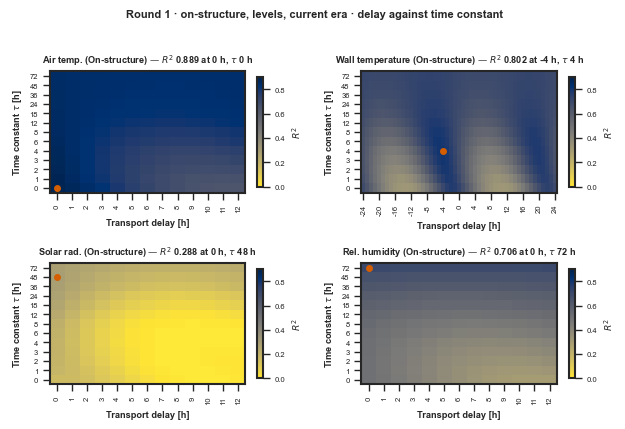

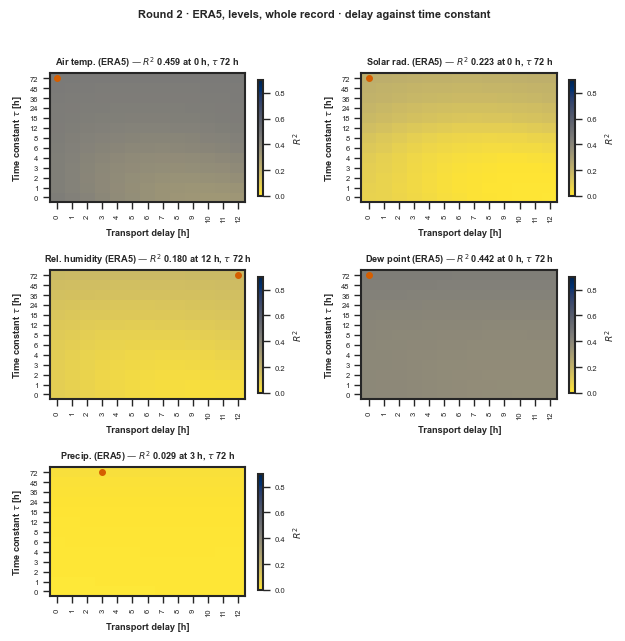

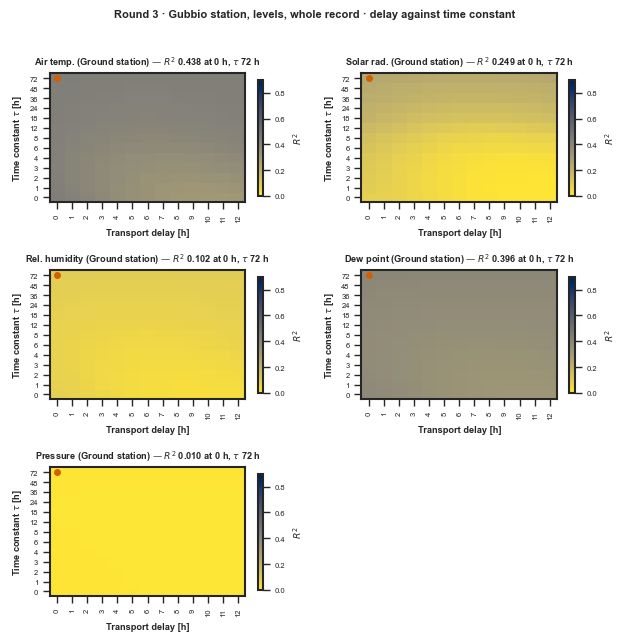

In [13]:
GRID_PANELS = [
    ('current', coupling.BAND_LEVEL,
     [driver for driver in ('tair_str', 'twall_str', 'sr_str', 'rh_str')
      if driver in DRIVERS_STR]),
    ('all', coupling.BAND_LEVEL,
     [driver for driver in FIGURE_DRIVERS_ERA5 if driver in DRIVERS_ERA5]),
    ('all', coupling.BAND_LEVEL,
     [driver for driver in FIGURE_DRIVERS_GS if driver in DRIVERS_GS]),
]
all_scans = {**scans_str, **scans_era5, **scans_gs}
OPERATOR_R2_MAX = coupling.r2_ceiling(all_scans, GRID_PANELS,
                                      step=OPERATOR_R2_STEP)
print(f'Shared colour scale for the operator grids: 0 to {OPERATOR_R2_MAX:.2f}')

for (stratum, band, panel_drivers), heading, artefact in zip(
        GRID_PANELS,
        ('Round 1 · on-structure, levels, current era',
         'Round 2 · ERA5, levels, whole record',
         'Round 3 · Gubbio station, levels, whole record'),
        ('TR_F07_operator_grid_str', 'TR_F08_operator_grid_era5',
         'TR_F09_operator_grid_gs')):
    figures.plot_operator_grid(
        all_scans, stratum, band, panel_drivers,
        title=f'{heading} · delay against time constant',
        vmin=0.0, vmax=OPERATOR_R2_MAX,
        width=FIGSIZE_WIDTH, save_path=OUTPUT_DIR, filename=artefact)

In [14]:
coupling_table = pd.concat([table_str, table_era5, table_gs], ignore_index=True)
coupling_table.to_csv(f'{OUTPUT_DIR}/TR_02_coupling_all.csv', index=False)

verdict = coupling.shortlist(coupling_table, control=CONTROL_DRIVER,
                             expected_sign=EXPECTED_SIGN)
pooled = verdict[verdict['stratum'] == 'all'].copy()
display(pooled.sort_values(['band', 'driver']))

,stratum,band,driver,lag,tau,r,r2,n,slope,slope_se,ci_low,ci_high,intercept,r2_instantaneous,gain_from_operator,causal_r2,r2_lost_to_causality,tau_at_edge,sign,control_r,clears_control,gain_significant,expected_sign
280,all,diurnal,pres_gs,10.0,0.0,-0.258698,0.066925,43139,-2.561724,0.120351,-2.797607,-2.325842,0.009014,0.013549,0.053375,0.066925,0.000000,False,-,0.138815,True,True,True
154,all,diurnal,rain_era5,12.0,0.0,0.060117,0.003614,46361,1.761120,0.173047,1.421954,2.100286,0.020460,0.000549,0.003065,0.003614,0.000000,False,+,0.138815,False,True,False
287,all,diurnal,rain_gs,0.0,0.0,0.051545,0.002657,43927,1.501770,0.160590,1.187019,1.816522,0.011243,0.002657,0.000000,0.002657,0.000000,False,+,0.138815,False,True,False
294,all,diurnal,rain_rate_gs,0.0,0.0,0.040856,0.001669,43926,0.098488,0.019516,0.060236,0.136740,0.011176,0.001669,0.000000,0.001669,0.000000,False,+,0.138815,False,True,False
133,all,diurnal,rh_era5,0.0,0.0,0.685626,0.470084,46332,0.457880,0.006309,0.445515,0.470246,-0.156525,0.470084,0.000000,0.470084,0.000000,False,+,0.138815,True,True,False
259,all,diurnal,rh_gs,0.0,0.0,0.712666,0.507892,42715,0.544267,0.007247,0.530063,0.558471,-0.143881,0.507892,0.000000,0.507892,0.000000,False,+,0.138815,True,True,False
42,all,diurnal,rh_str,0.0,0.0,0.794699,0.631547,46885,0.647761,0.007917,0.632245,0.663278,-0.203490,0.631547,0.000000,0.631547,0.000000,False,+,0.138815,True,True,False
147,all,diurnal,sr_era5,0.0,0.0,-0.874345,0.764480,46332,-0.031661,0.000277,-0.032205,-0.031117,-0.281048,0.764480,0.000000,0.764480,0.000000,False,-,0.138815,True,True,True
301,all,diurnal,sr_gs,0.0,0.0,-0.878354,0.771505,43926,-0.034198,0.000286,-0.034759,-0.033638,-0.314940,0.771505,0.000000,0.771505,0.000000,False,-,0.138815,True,True,True
49,all,diurnal,sr_str,1.0,0.0,-0.866793,0.751329,5008,-0.026233,0.000615,-0.027439,-0.025027,-0.442645,0.741243,0.010086,0.751329,0.000000,False,-,0.138815,True,True,True


In [15]:
# The level band and the diurnal band, written separately: the report reads them as two tables
# because they are two results, and a reader comparing them should not have to filter a column.
for band, artefact in ((coupling.BAND_LEVEL, 'TR_T03_coupling_level'),
                       (coupling.BAND_DIURNAL, 'TR_T04_coupling_diurnal')):
    block = pooled[pooled['band'] == band]
    tables.write_table(
        block, f'{OUTPUT_DIR}/{artefact}.tex',
        columns=[('driver', tables.texttt),
                 ('lag', '.0f'),
                 ('tau', '.0f'),
                 ('r', '+.3f'),
                 ('gain_from_operator', '+.3f'),
                 ('slope', '+.3g'),
                 ('n', ',.0f'),
                 ('clears_control', tables.yes_no),
                 ('expected_sign', tables.yes_no)])
    block.to_csv(f'{OUTPUT_DIR}/{artefact.replace("_T0", "_0")}.csv', index=False)

**How to read TR_F05.** The leading driver overall against the response, both on the diurnal
band and with the driver delayed by the lag the scan chose. Each hexagon is a bin of paired
hours; its colour is the number of hours it holds, on a logarithmic scale, dark where the record
is dense and pale where a few hours sit. The line is the least-squares gain, in millidegrees of
inclination per unit of the driver, with a 95 % confidence interval computed from a
heteroskedasticity- and autocorrelation-consistent covariance, because consecutive hours are not
independent; r and n are the correlation and the number of paired hours. A negative slope is the
expected sign. What to look for: whether the cloud is a straight band, which supports a single
linear gain, and whether its width grows at the extremes, which is where one gain starts to
under-describe the response.

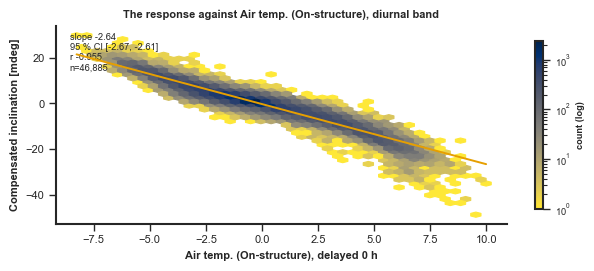

In [16]:
# The response against the strongest surviving driver, at the lag the scan chose.
admitted = pooled[(pooled['band'] == coupling.BAND_DIURNAL)
                  & pooled['clears_control'] & pooled['gain_significant']]
if len(admitted):
    leader = admitted.loc[admitted['r'].abs().idxmax()]
    banded = frame.apply(coupling.diurnal_band, window=DIURNAL_WINDOW,
                         min_periods=DIURNAL_MIN_PERIODS)
    figures.plot_coupling_scatter(
        banded, RESPONSE_COLUMN, leader['driver'], leader['lag'],
        tau=leader['tau'], gain=leader.to_dict(),
        title=f'The response against {viz.driver_label(leader["driver"])}, diurnal band',
        width=FIGSIZE_WIDTH, save_path=OUTPUT_DIR,
        filename='TR_F05_leading_driver_scatter')
else:
    print('No driver cleared the control with a significant gain; no scatter drawn.')

## Step 7.5 · Diurnal delay at native resolution

Step 3's diurnal band and step 7's coupling table both run on the hourly grid, and a delay read
off an hourly scan can only ever land on the hour: `TR_02_coupling_all.csv` reports zero to one
hour for the strongest radiation drivers, and that range is the rounding an hourly grid imposes
on the true delay, not a statement that the delay itself is unresolved below the hour. The
archive is twenty-minute native, and the same question — how far behind its drivers does the
wall run — resolved on that finer grid answers to the nearest twenty minutes instead.

The scan is a daily-demeaned Pearson correlation between the response, held at its own
timestamps, and each driver read at a candidate displacement —
`shmlib.temporal_alignment.reference_shift_scan`, written for study 5's clock-alignment question
and reused here for a physical delay instead of a clock correction. A positive displacement `d`
reads the driver later than the response's own timestamp; where the driver genuinely leads the
response by some delay, the best alignment is found by reading the driver *earlier* than the
response, which is a negative `d`, so the delay this step reports is `-d`. Demeaning each day
before correlating removes the response's own drift and its arbitrary anchor first, for the same
reason step 3 separates the diurnal band from the level before either is read.

The two instrument eras are scanned separately rather than pooled. `sr_str` and every other
current-only channel exist from 2025-02-21 on, and a pooled scan across both eras would silently
answer for whichever era carries more days rather than reporting that the legacy era has nothing
to say about radiation at all. A cell without `MIN_PAIRS` paired samples or `MIN_DAYS` distinct
days is reported as insufficient rather than as a number that happens to have very little behind
it.

### Parameter Tuning Guidance

`NATIVE_FREQ` is the grid this step runs on. `DELAY_SHIFTS_MINUTES` bounds the scan and must be
multiples of `NATIVE_FREQ`; every candidate here is at twenty-minute steps out to four hours
either way. `DELAY_PERIODS` names the two eras and their bounds. `GROUND_STAMP_OFFSET` corrects
the station's stamp exactly as study 2 does, before the scan ever sees it. `MIN_PAIRS` and
`MIN_DAYS` are the same two-part support rule `MIN_PAIRED_HOURS` applies to the hourly scan
above, restated for the finer grid.

In [ ]:
sensor_native_current, _ = proxies.load_sensor_forcings(
    ARCHIVE_CSV, column_map=STR_MAP_CURRENT, freq=NATIVE_FREQ, tz=SITE_TZ,
    honour_suspect=HONOUR_SUSPECT, min_count=1)
sensor_native_legacy, _ = proxies.load_sensor_forcings(
    ARCHIVE_CSV, column_map=STR_MAP_LEGACY, freq=NATIVE_FREQ, tz=SITE_TZ,
    honour_suspect=HONOUR_SUSPECT, min_count=1)
sensor_native = proxies.join_eras([sensor_native_current, sensor_native_legacy])

era5_native_hourly = proxies.load_era5(ERA5_CSV, column_map=ERA5_MAP, freq='1h')
era5_native = proxies.to_native_grid(era5_native_hourly, freq=NATIVE_FREQ,
                                     accumulations=('sr',))

ground_native_half_hourly = proxies.load_ground_station(
    GROUND_STATION_CSV, column_map=GS_MAP, freq='30min', min_count=1,
    stamp_offset=GROUND_STAMP_OFFSET)
ground_native = proxies.to_native_grid(ground_native_half_hourly, freq=NATIVE_FREQ,
                                       accumulations=())

response_native, _ = proxies.load_response(
    ARCHIVE_CSV, column=RESPONSE_COLUMN, honour_spike=HONOUR_INC_SPIKE,
    freq=NATIVE_FREQ, tz=SITE_TZ, min_count=1)

native_frame = proxies.harmonise([sensor_native, ground_native, era5_native],
                                 freq=NATIVE_FREQ)
native_frame, n_masked_native = proxies.mask_implausible(native_frame)
native_frame[RESPONSE_COLUMN] = response_native.reindex(native_frame.index)
print(f'Native frame: {len(native_frame):,} slots at {NATIVE_FREQ}, '
      f'implausible values masked: {int(n_masked_native.sum())}')

In [ ]:
# One pair per driver: the response, unmoved, against each candidate displaced. The pair label
# carries the source (line style in the figure below) and the variable carries the quantity
# (colour), matching `shmlib.figures.plot_reference_shift_scan` exactly.
DELAY_PAIRS = (
    ('str', 'tair', RESPONSE_COLUMN, 'tair_str'),
    ('gs', 'tair', RESPONSE_COLUMN, 'tair_gs'),
    ('era5', 'tair', RESPONSE_COLUMN, 'tair_era5'),
    ('str', 'sr', RESPONSE_COLUMN, 'sr_str'),
    ('gs', 'sr', RESPONSE_COLUMN, 'sr_gs'),
    ('era5', 'sr', RESPONSE_COLUMN, 'sr_era5'),
)
native_scan = temporal_alignment.scan_reference_pairs(
    {'native': native_frame}, DELAY_PAIRS, DELAY_PERIODS, DELAY_SHIFTS_MINUTES,
    freq=NATIVE_FREQ, min_pairs=MIN_PAIRS, min_days=MIN_DAYS)
native_scan['status'] = np.where(
    (native_scan['n_pairs'] >= MIN_PAIRS) & (native_scan['n_days'] >= MIN_DAYS),
    'ok', 'insufficient_support')
native_scan.to_csv(f'{OUTPUT_DIR}/TR_07_native_delay_scan.csv', index=False)
display(native_scan[native_scan['shift_minutes'] == 0])

In [ ]:
# Correlations from a cell this scan marked insufficient are blanked before the argmax is taken,
# so a driver with no support anywhere reports as unidentified rather than as a number computed
# from a handful of days.
scored = native_scan.copy()
scored.loc[scored['status'] != 'ok', 'r_daily'] = np.nan
native_summary = temporal_alignment.shift_summary(
    scored, group_cols=('period', 'variable', 'pair'),
    shift_col='shift_minutes', r_col='r_daily')
native_summary['driver'] = native_summary['variable'] + '_' + native_summary['pair']
native_summary['delay_minutes'] = -native_summary['shift_argmax']
native_summary['status'] = np.where(native_summary['shift_argmax'].notna(),
                                    'ok', 'insufficient_support')
native_summary = native_summary.sort_values(
    ['period', 'variable', 'pair']).reset_index(drop=True)
display(native_summary)
native_summary.to_csv(f'{OUTPUT_DIR}/TR_08_native_delay_summary.csv', index=False)

# The delay convention, stated once rather than only in the caption below: `shift_minutes` reads
# the driver later than the response when positive, and `delay_minutes` is its negation, so a
# positive delay means the response follows the driver by that many minutes and a negative one
# means the response precedes it. `shift_summary`'s own `sign` column describes `shift_argmax`,
# not the negated `delay_minutes` the table reports, so it is left out of the table rather than
# printed next to a number it does not describe.
tables.write_table(
    native_summary, f'{OUTPUT_DIR}/TR_T08_native_delay_summary.tex',
    columns=[('period', None),
             ('driver', tables.texttt),
             ('delay_minutes', '+.0f'),
             ('r_argmax', '+.3f'),
             ('r_shift0', '+.3f')])

**How to read TR_F10.** One row per instrument era, one column per driver variable, one curve
per source family: solid for on-structure, dashed for the ground station, dotted for ERA5. The
horizontal axis is the delay of the response behind the driver, in minutes: at +40 the driver's
value 40 minutes earlier is paired with the response now. The vertical axis is the Pearson
correlation of the two after each day's mean has been removed from both, so the inclination's
drift and its arbitrary anchor play no part. The expected sign is negative, so the reading is the
minimum of each curve; the accent dot marks it and its label gives the delay. When a delay is a
property of the wall rather than of a sensor, the three sources of one variable agree to within a
slot or two: for radiation they do, at about 40 minutes, once the station is placed at its
interval centre by `GROUND_STAMP_OFFSET`. For air temperature the on-structure curve bottoms out
at zero delay while the station and ERA5 curves bottom out at a negative delay, which means the
wall moves before the free air warms: the wall follows the sun, and the on-structure air probe in
its sun-exposed housing follows the sun too. The curves are V-shaped rather than cosine-shaped
because the scan spans only four hours either way of a 24-hour cycle. A cell the legacy era
cannot support, such as on-structure radiation before 2025-02-21, is left out of that row.

In [ ]:
figures.plot_reference_shift_scan(
    native_scan, variables=('tair', 'sr'), pairs=['str', 'gs', 'era5'],
    variable_col='variable', pair_col='pair',
    row_col='period', row_order=['legacy', 'current'],
    negate_x=True, x_label='Delay of the response behind the driver [min]',
    mark_extreme=True, extreme_label='corner',
    pair_labels={'str': 'On-structure', 'gs': 'Ground station', 'era5': 'ERA5'},
    title='Diurnal delay at native resolution, both eras',
    save_path=OUTPUT_DIR, filename='TR_F10_native_delay_scan')

The wall follows radiation by twenty to forty minutes across the three sources and both eras —
forty minutes exactly against ERA5 in the current era — not the zero-to-one-hour range
`TR_T04_coupling_diurnal.tex` reports from the hourly grid. That range is the hourly grid's
rounding of this same delay, not a separate or contradicting finding: forty minutes rounds to
either zero or one hour depending on which side of the half-hour the true value falls, and the
hourly scan cannot say which. Against air temperature the relationship runs the other way — the
wall leads rather than follows, by forty to eighty minutes across sources and eras — consistent
with the heating driver reaching the surface that governs the inclination before the air
temperature above it has finished responding to the same forcing. `tair_str`'s optimum sits at
zero delay in both eras, the one driver co-located with the response in the same on-structure
housing. Every recovered correlation is negative, the sign the site's geometry predicts
(`EXPECTED_SIGN`, § 7.5), with no exception. `sr_str` has no scoreable cell in the legacy era,
correctly: the current-era package that carries it did not exist before 2025-02-21.

## Step 8 · Stability

Every gain above is a single number fitted over a whole record, and a single season can produce
one on its own: a driver active only in summer, or a coincidence between two slow drifts, both
give a respectable pooled slope. Re-fitting the same lag month by month separates the two. A
real coupling holds its slope, within its uncertainty, across months in which the driver's own
range changes.

### Parameter Tuning Guidance

`STABILITY_FREQ` sets the window — calendar months here, which the post-outage record supports.
`STABILITY_MIN_HOURS` is the paired hours a window needs before its gain is reported at all.

**How to read TR_F06.** One panel per shortlisted driver. The scan of step 7 chose one lag per
driver on the pooled record; here the gain is re-fitted month by month at that fixed lag, so
that a coupling which only holds on average is told apart from one that holds in every month.
The line is the monthly gain, in millidegrees per unit of the driver, and the band its 95 %
confidence interval; the grey line is zero, and the lag each panel uses is written on it. The
panels have different vertical scales because the drivers have different units, so compare
shapes rather than heights. What to look for: a gain that keeps its sign in every month, which is
the minimum a physical coupling must do; a seasonal swing, which says the gain depends on the
wall's thermal state and that a single number is a compromise; and a band that widens or a line
that jumps, which marks months where the driver or the response is thin. Panels that begin in
2025 belong to channels that exist only in the current instrument era.

,window,driver,lag,tau,slope,slope_se,ci_low,ci_high,r,n
0,2018-07-01,rh_str,0.0,0.0,1.211853,0.063901,1.086608,1.337098,0.954533,140
1,2018-08-01,rh_str,0.0,0.0,0.836405,0.042239,0.753618,0.919192,0.903583,676
2,2018-09-01,rh_str,0.0,0.0,0.715115,0.034563,0.647374,0.782857,0.913384,503
3,2018-11-01,rh_str,0.0,0.0,0.344067,0.044947,0.255973,0.432162,0.535078,222
4,2018-12-01,rh_str,0.0,0.0,0.184769,0.034935,0.116297,0.253241,0.387350,672
5,2019-01-01,rh_str,0.0,0.0,0.251695,0.065592,0.123138,0.380253,0.475443,245
6,2019-02-01,rh_str,0.0,0.0,0.382678,0.037769,0.308651,0.456704,0.634683,551
7,2019-03-01,rh_str,0.0,0.0,0.463170,0.040218,0.384344,0.541996,0.768437,704
8,2019-04-01,rh_str,0.0,0.0,0.488306,0.039160,0.411553,0.565059,0.801499,342
9,2019-05-01,rh_str,0.0,0.0,0.471306,0.028850,0.414762,0.527850,0.845282,478


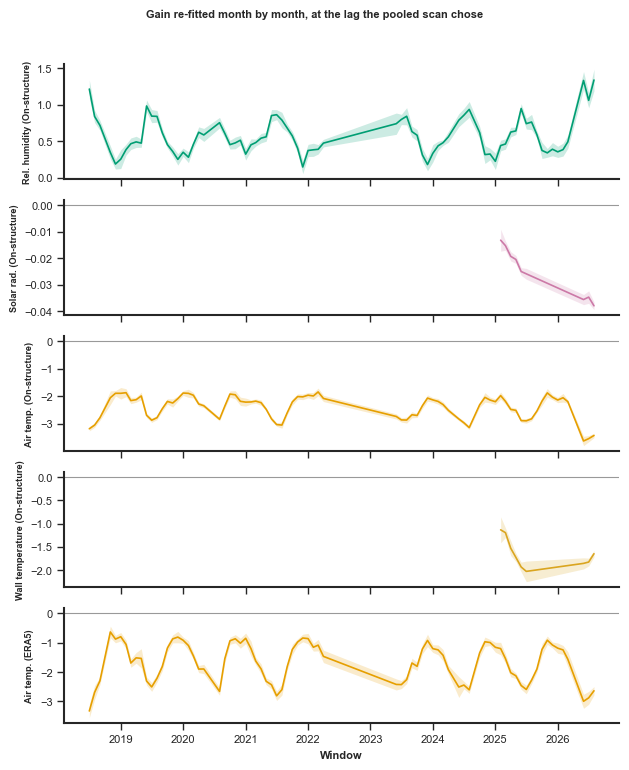

In [17]:
shortlisted = list(dict.fromkeys(admitted['driver'])) if len(admitted) else []
if shortlisted:
    banded = frame.apply(coupling.diurnal_band, window=DIURNAL_WINDOW,
                         min_periods=DIURNAL_MIN_PERIODS)
    lags_at = {row['driver']: row['lag'] for _, row in admitted.iterrows()}
    taus_at = {row['driver']: row['tau'] for _, row in admitted.iterrows()}
    stability = coupling.gain_stability(
        banded, RESPONSE_COLUMN, shortlisted, lags_at, taus=taus_at,
        freq=STABILITY_FREQ, min_paired=STABILITY_MIN_HOURS,
        hac_maxlags=HAC_MAXLAGS)
    display(stability.head(20))
    stability.to_csv(f'{OUTPUT_DIR}/TR_05_gain_stability.csv', index=False)

    figures.plot_gain_stability(
        stability, drivers=shortlisted[:5],
        title='Gain re-fitted month by month, at the lag the pooled scan chose',
        width=FIGSIZE_WIDTH, lags=lags_at, save_path=OUTPUT_DIR,
        filename='TR_F06_gain_stability')
else:
    stability = pd.DataFrame()
    print('Nothing shortlisted; stability not computed.')

## Step 9 · The verdict

What couples to the wall, at what lag, with what sign, and on what evidence. Three conditions
are reported separately rather than combined into a single pass or fail, because a driver can
fail one and pass another and the report should say which: whether it clears the negative
control, whether its gain's confidence interval excludes zero, and whether its sign is the one
the site's geometry predicts.

The sign column is where this study meets § 7.5. The expectation is negative. Where a driver
clears the control with a significant gain of the expected sign, the site's convention and this
record agree. Where it clears with the opposite sign, that is a fact to report beside the
expectation, not a coefficient to flip.

In [18]:
summary = (verdict[verdict['stratum'] == 'all']
           .sort_values(['band', 'driver'])
           [['band', 'driver', 'lag', 'tau', 'tau_at_edge', 'r', 'r2',
             'r2_instantaneous', 'gain_from_operator', 'r2_lost_to_causality',
             'slope', 'slope_se', 'ci_low', 'ci_high', 'n', 'control_r',
             'clears_control', 'gain_significant', 'expected_sign']])
display(summary)
summary.to_csv(f'{OUTPUT_DIR}/TR_06_verdict.csv', index=False)

tables.write_table(
    summary, f'{OUTPUT_DIR}/TR_T06_verdict.tex',
    columns=[('band', None),
             ('driver', tables.texttt),
             ('lag', '.0f'),
             ('tau', '.0f'),
             ('r', '+.3f'),
             ('gain_from_operator', '+.3f'),
             ('slope', '+.3g'),
             ('n', ',.0f'),
             ('clears_control', tables.yes_no),
             ('gain_significant', tables.yes_no),
             ('expected_sign', tables.yes_no)])

print(f'Response          {RESPONSE_COLUMN}')
print(f'Control           {CONTROL_DRIVER}')
print(f'Expected sign     {EXPECTED_SIGN} (docs/raw-data-format.md § 7.5)')
print(f'Drivers screened  {len(summary[summary["band"] == coupling.BAND_LEVEL])}')
print(f'Shortlisted       {len(shortlisted)}')
print(f'Operator grid     delays to {MAX_LAG_EXTERNAL} h, tau to {max(TAUS):.0f} h')
at_edge = summary[summary['tau_at_edge']]
print(f'Tau unidentified  {len(at_edge)} rows at the top of the grid'
      f' ({", ".join(sorted(at_edge["driver"].unique())) if len(at_edge) else "none"})')

,band,driver,lag,tau,tau_at_edge,r,r2,r2_instantaneous,gain_from_operator,r2_lost_to_causality,slope,slope_se,ci_low,ci_high,n,control_r,clears_control,gain_significant,expected_sign
280,diurnal,pres_gs,10.0,0.0,False,-0.258698,0.066925,0.013549,0.053375,0.000000,-2.561724,0.120351,-2.797607,-2.325842,43139,0.138815,True,True,True
154,diurnal,rain_era5,12.0,0.0,False,0.060117,0.003614,0.000549,0.003065,0.000000,1.761120,0.173047,1.421954,2.100286,46361,0.138815,False,True,False
287,diurnal,rain_gs,0.0,0.0,False,0.051545,0.002657,0.002657,0.000000,0.000000,1.501770,0.160590,1.187019,1.816522,43927,0.138815,False,True,False
294,diurnal,rain_rate_gs,0.0,0.0,False,0.040856,0.001669,0.001669,0.000000,0.000000,0.098488,0.019516,0.060236,0.136740,43926,0.138815,False,True,False
133,diurnal,rh_era5,0.0,0.0,False,0.685626,0.470084,0.470084,0.000000,0.000000,0.457880,0.006309,0.445515,0.470246,46332,0.138815,True,True,False
259,diurnal,rh_gs,0.0,0.0,False,0.712666,0.507892,0.507892,0.000000,0.000000,0.544267,0.007247,0.530063,0.558471,42715,0.138815,True,True,False
42,diurnal,rh_str,0.0,0.0,False,0.794699,0.631547,0.631547,0.000000,0.000000,0.647761,0.007917,0.632245,0.663278,46885,0.138815,True,True,False
147,diurnal,sr_era5,0.0,0.0,False,-0.874345,0.764480,0.764480,0.000000,0.000000,-0.031661,0.000277,-0.032205,-0.031117,46332,0.138815,True,True,True
301,diurnal,sr_gs,0.0,0.0,False,-0.878354,0.771505,0.771505,0.000000,0.000000,-0.034198,0.000286,-0.034759,-0.033638,43926,0.138815,True,True,True
49,diurnal,sr_str,1.0,0.0,False,-0.866793,0.751329,0.741243,0.010086,0.000000,-0.026233,0.000615,-0.027439,-0.025027,5008,0.138815,True,True,True


Response          inc_comp_cleaned
Control           batt_str
Expected sign     - (docs/raw-data-format.md § 7.5)
Drivers screened  22
Shortlisted       18
Operator grid     delays to 12 h, tau to 72 h
Tau unidentified  17 rows at the top of the grid (pres_gs, rain_era5, rain_gs, rh_era5, rh_gs, rh_str, sr_era5, sr_gs, tair_era5, tair_gs, tdew_era5, tdew_gs, wdir_cos_era5, wdir_cos_gs, wdir_sin_gs, wspd_era5, wspd_gs)
